# 03 - Preprocessing Ablation (top-2 models)

**Phase 3.** How much does each cleaning step actually help? The supervisor asked us to
keep this small: run it on the **top-2 models only** (from Phase 2's `top_models.json`) and
a handful of meaningful configurations, not the full permutation grid.

- **Top-2 models** and each one's *Phase-2-winning* representation:
  Linear SVM (TF-IDF unigram) and Logistic Regression (TF-IDF bigram).
- **Five ablation configs** (toggling `clean()`): baseline (lowercase + remove punct),
  +stopword removal, +stemming, +both, and *minimal* (keep punctuation).
- **One anchor row per model** — the *exact Phase-2 pipeline* (`clean()` defaults + the
  model's Phase-2 vectorizer with `min_df=2`). This is a **reproducibility check**, not a
  sixth ablation arm: it must reproduce the Phase-2 metric to 4 dp, confirming the persisted
  split reloaded identically.

Design (leakage-free): each config cleans the text *outside* CV (a deterministic per-message
map, no fitting), then feeds a `Pipeline([vectorizer, classifier])` to `GridSearchCV`, so the
vectorizer is still fitted on training folds only. The five ablation configs use
`token_pattern=r"\S+"` + `lowercase=False` so `clean()` fully controls tokenization (incl.
keeping punctuation for the *minimal* config); the anchor uses the Phase-2 default tokenizer.


In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")  # precede numpy import (project-wide OpenMP guard)

import sys, json
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.preprocessing import load_dataset, make_split, clean
from src.features import bow, tfidf_unigram, tfidf_ngram
from src.models import get_models
from src.evaluation import run_master_grid

sns.set_theme(style="whitegrid")
RESULTS = config.RESULTS_DIR
np.random.seed(config.RANDOM_SEED)
MIN_DF = 2  # matches Phase 2 (notebook 02 used min_df=2)
print("Results dir:", RESULTS)

Results dir: /home/sdd/Documents/ovi/final year project/results


## 1. Load data, reuse the persisted split, and pre-flight

Two guards before any modelling:
1. **Row-count assert** against `results/eda_summary.csv` (`rows_dedup`) so a silent change in
   `load_dataset()` is caught here rather than surfacing as an unexplained anchor drift.
2. **NLTK pre-flight** — load the stopword list and stemmer up front so a missing resource
   fails loudly in the first cell, never mid-run.

In [2]:
df = load_dataset()

# Guard 1: row count must match what notebook 01 persisted (do not hard-code the number).
eda = pd.read_csv(RESULTS / "eda_summary.csv")
expected_rows = int(eda["rows_dedup"].iloc[0])
assert len(df) == expected_rows, f"row count changed: got {len(df)}, expected {expected_rows}"
print(f"row-count OK: {len(df)} == rows_dedup from eda_summary.csv")

X_train, X_test, y_train, y_test = make_split(df)  # reloads results/split_indices.npz
print(f"train={len(X_train)}  test={len(X_test)}  "
      f"(train spam%={100*y_train.mean():.2f}, test spam%={100*y_test.mean():.2f})")

# Guard 2: NLTK resources load now, not mid-run.
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
_ = stopwords.words("english"); _ = PorterStemmer().stem("running")
print("NLTK pre-flight OK (stopwords + PorterStemmer available)")

row-count OK: 5158 == rows_dedup from eda_summary.csv
train=4126  test=1032  (train spam%=12.46, test spam%=12.40)


NLTK pre-flight OK (stopwords + PorterStemmer available)


## 2. Define the top-2 models, their Phase-2 vectorizers, and the config set

We read the two winners from `results/top_models.json` and their exact Phase-2 metrics from
`results/master_metrics.csv` (no hand-typed numbers) — those metrics are the anchor targets.

In [3]:
top = json.load(open(RESULTS / "top_models.json"))
models_all = get_models()  # scale_pos_weight irrelevant: top-2 are LinearSVM & LogisticRegression

# representation name -> factory that accepts vectorizer kwargs
rep_builders = {
    "bow":           lambda **kw: bow(**kw),
    "tfidf_unigram": lambda **kw: tfidf_unigram(**kw),
    "tfidf_bigram":  lambda **kw: tfidf_ngram(max_n=2, **kw),
    "tfidf_trigram": lambda **kw: tfidf_ngram(max_n=3, **kw),
}

mm = pd.read_csv(RESULTS / "master_metrics.csv")
def phase2_target(model, rep):
    r = mm[(mm["model"] == model) & (mm["representation"] == rep)].iloc[0]
    return float(r["f1"]), float(r["fpr"])

# The five ablation configs (label -> clean() toggles). All share the \S+ tokenizer below.
ABLATION = [
    ("baseline",               dict(lowercase=True, remove_punct=True,  remove_stopwords=False, stem=False)),
    ("baseline+stopword",      dict(lowercase=True, remove_punct=True,  remove_stopwords=True,  stem=False)),
    ("baseline+stem",          dict(lowercase=True, remove_punct=True,  remove_stopwords=False, stem=True)),
    ("baseline+stopword+stem", dict(lowercase=True, remove_punct=True,  remove_stopwords=True,  stem=True)),
    ("minimal_keeppunct",      dict(lowercase=True, remove_punct=False, remove_stopwords=False, stem=False)),
]
print("Top-2:", [(m["model"], m["representation"]) for m in top])
print("Ablation configs:", [c for c, _ in ABLATION])

Top-2: [('LinearSVM', 'tfidf_unigram'), ('LogisticRegression', 'tfidf_bigram')]
Ablation configs: ['baseline', 'baseline+stopword', 'baseline+stem', 'baseline+stopword+stem', 'minimal_keeppunct']


## 3. Run the anchor first (the reproducibility gate)

If the anchor does not reproduce Phase 2 to 4 dp, nothing downstream is worth computing, so we
run it first and `assert` on it. A passing anchor confirms the split reloaded identically.

In [4]:
cv = config.get_cv(5)

def clean_texts(Xtr, Xte, toggles):
    return (np.array([clean(t, **toggles) for t in Xtr]),
            np.array([clean(t, **toggles) for t in Xte]))

def n_test_in_train(train_texts, test_texts):
    s = set(train_texts.tolist())
    return int(sum(t in s for t in test_texts))

def run_config(model_name, rep_name, vec_factory, Xtr, Xte, kind, label):
    estimator, grid = models_all[model_name]
    res, fitted = run_master_grid(
        {model_name: (estimator, grid)}, {rep_name: vec_factory},
        Xtr, y_train, Xte, y_test, cv, verbose=False,
    )
    row = res.iloc[0].to_dict()
    row["config"] = label
    row["kind"] = kind
    row["n_test_in_train"] = n_test_in_train(Xtr, Xte)
    row["vocab_size"] = len(fitted[(model_name, rep_name)].named_steps["vec"].vocabulary_)
    return row

# Anchor = clean() defaults + Phase-2 vectorizer (min_df=2, default tokenizer/lowercase).
Xtr_def, Xte_def = clean_texts(X_train, X_test, {})  # {} -> clean() defaults
rows = []
for m in top:
    mn, rn = m["model"], m["representation"]
    builder = rep_builders[rn]
    vec = (lambda _b=builder: _b(min_df=MIN_DF))
    row = run_config(mn, rn, vec, Xtr_def, Xte_def, "repro_check", "anchor_phase2")
    tf1, tfpr = phase2_target(mn, rn)
    ok = np.isclose(row["f1"], tf1, atol=1e-4) and np.isclose(row["fpr"], tfpr, atol=1e-4)
    print(f"{mn:20s} anchor f1={row['f1']:.4f} (target {tf1:.4f})  "
          f"fpr={row['fpr']:.4f} (target {tfpr:.4f})  -> {'OK' if ok else 'DRIFT!'}")
    assert ok, f"ANCHOR DRIFT for {mn}: Phase-2 reproduction failed — stop and diagnose"
    rows.append(row)
print("\nAll anchors reproduce Phase 2 to 4 dp -> persisted split reloaded identically.")

LinearSVM            anchor f1=0.9482 (target 0.9482)  fpr=0.0044 (target 0.0044)  -> OK


LogisticRegression   anchor f1=0.9444 (target 0.9444)  fpr=0.0055 (target 0.0055)  -> OK

All anchors reproduce Phase 2 to 4 dp -> persisted split reloaded identically.


## 4. Run the five ablation configs (both models)

Each config cleans the text with its toggles, then vectorizes with `token_pattern=r"\S+"`,
`lowercase=False`, `min_df=2` so `clean()` controls tokenization. We record vocab size and
train-test overlap per config as sanity signals (we do **not** re-deduplicate — that would
break the single persisted split).

In [5]:
for label, toggles in ABLATION:
    Xtr_c, Xte_c = clean_texts(X_train, X_test, toggles)
    for m in top:
        mn, rn = m["model"], m["representation"]
        builder = rep_builders[rn]
        vec = (lambda _b=builder: _b(min_df=MIN_DF, token_pattern=r"\S+", lowercase=False))
        row = run_config(mn, rn, vec, Xtr_c, Xte_c, "ablation", label)
        rows.append(row)
        print(f"[{label:24s}] {mn:20s} f1={row['f1']:.4f} fpr={row['fpr']:.4f} "
              f"vocab={row['vocab_size']:5d} test_in_train={row['n_test_in_train']}")

adf = pd.DataFrame(rows)

# Sanity: keep-punct vocab must exceed baseline vocab, else punctuation never reached the vectorizer.
for m in top:
    mn = m["model"]
    v_base = int(adf[(adf.model == mn) & (adf.config == "baseline")]["vocab_size"].iloc[0])
    v_kp   = int(adf[(adf.model == mn) & (adf.config == "minimal_keeppunct")]["vocab_size"].iloc[0])
    assert v_kp > v_base, f"{mn}: keep-punct vocab {v_kp} !> baseline {v_base} (punct not retained)"
    print(f"{mn:20s} baseline vocab={v_base}, keep-punct vocab={v_kp}  OK (punctuation retained)")

# Persist (stringify best_params so it survives the CSV round-trip).
out = adf.copy()
out["best_params"] = out["best_params"].astype(str)
col_order = ["model", "representation", "config", "kind", "accuracy", "precision", "recall",
             "f1", "fpr", "auc", "cv_best_f1", "vocab_size", "n_test_in_train",
             "tp", "fp", "tn", "fn", "best_params"]
out[col_order].to_csv(RESULTS / "ablation.csv", index=False)
print("\nSaved results/ablation.csv", out.shape)
out[["model", "config", "kind", "f1", "fpr", "vocab_size", "n_test_in_train"]].round(4)

[baseline                ] LinearSVM            f1=0.9317 fpr=0.0055 vocab= 3218 test_in_train=7


[baseline                ] LogisticRegression   f1=0.9402 fpr=0.0055 vocab=10341 test_in_train=7


[baseline+stopword       ] LinearSVM            f1=0.9286 fpr=0.0077 vocab= 3093 test_in_train=8


[baseline+stopword       ] LogisticRegression   f1=0.9291 fpr=0.0088 vocab= 6311 test_in_train=8


[baseline+stem           ] LinearSVM            f1=0.9312 fpr=0.0044 vocab= 2851 test_in_train=7


...

[baseline+stopword+stem  ] LinearSVM            f1=0.9194 fpr=0.0066 vocab= 2752 test_in_train=8


[baseline+stopword+stem  ] LogisticRegression   f1=0.9170 fpr=0.0100 vocab= 6170 test_in_train=8


[minimal_keeppunct       ] LinearSVM            f1=0.9398 fpr=0.0044 vocab= 3336 test_in_train=0


[minimal_keeppunct       ] LogisticRegression   f1=0.9482 fpr=0.0044 vocab=12385 test_in_train=0
LinearSVM            baseline vocab=3218, keep-punct vocab=3336  OK (punctuation retained)
LogisticRegression   baseline vocab=10341, keep-punct vocab=12385  OK (punctuation retained)

Saved results/ablation.csv (12, 18)


,model,config,kind,f1,fpr,vocab_size,n_test_in_train
0,LinearSVM,anchor_phase2,repro_check,0.9482,0.0044,3183,7
1,LogisticRegression,anchor_phase2,repro_check,0.9444,0.0055,9622,7
2,LinearSVM,baseline,ablation,0.9317,0.0055,3218,7
3,LogisticRegression,baseline,ablation,0.9402,0.0055,10341,7
4,LinearSVM,baseline+stopword,ablation,0.9286,0.0077,3093,8
5,LogisticRegression,baseline+stopword,ablation,0.9291,0.0088,6311,8
6,LinearSVM,baseline+stem,ablation,0.9312,0.0044,2851,7
7,LogisticRegression,baseline+stem,ablation,0.9444,0.0055,10119,7
8,LinearSVM,baseline+stopword+stem,ablation,0.9194,0.0066,2752,8
9,LogisticRegression,baseline+stopword+stem,ablation,0.9170,0.0100,6170,8


## 5. Ablation figure

Grouped bars of F1 and FPR across the **five ablation configs**, one group of bars per model.
(The anchor is a Phase-2 reproduction on a different tokenizer, so it is reported in the table
but excluded from the ablation bars to keep the comparison like-for-like.)

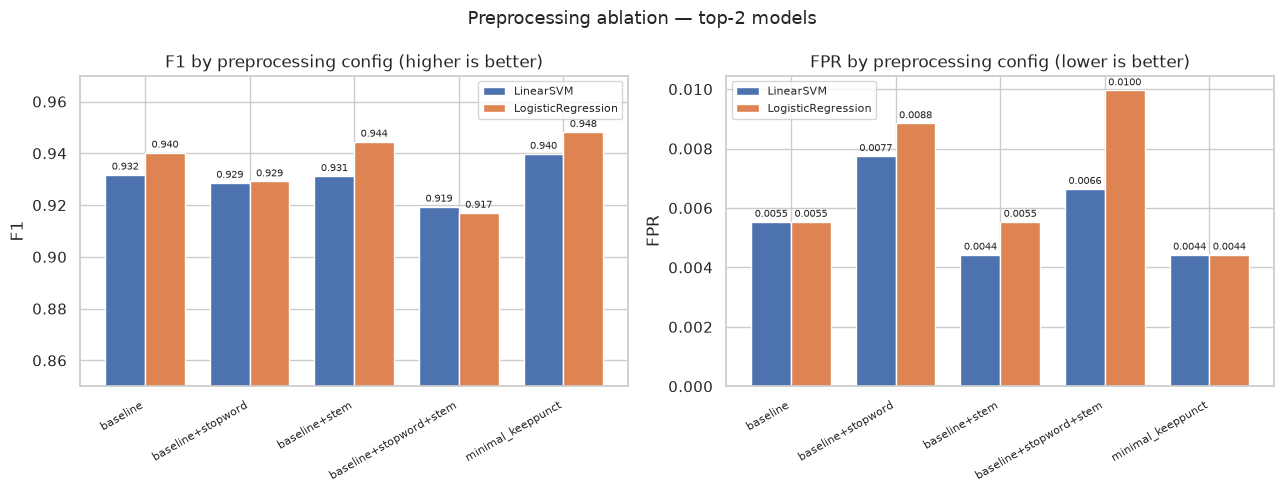

Saved results/fig_ablation.png


In [6]:
plot_df = adf[adf.kind == "ablation"].copy()
cfg_order = [c for c, _ in ABLATION]
model_order = [m["model"] for m in top]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, fmt, better in [
    (axes[0], "f1", "%.3f", "higher is better"),
    (axes[1], "fpr", "%.4f", "lower is better"),
]:
    x = np.arange(len(cfg_order))
    w = 0.38
    for j, mn in enumerate(model_order):
        vals = [float(plot_df[(plot_df.model == mn) & (plot_df.config == c)][metric].iloc[0])
                for c in cfg_order]
        bars = ax.bar(x + (j - 0.5) * w, vals, w, label=mn)
        ax.bar_label(bars, fmt=fmt, fontsize=7, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(cfg_order, rotation=30, ha="right", fontsize=8)
    ax.set_title(f"{metric.upper()} by preprocessing config ({better})")
    ax.set_ylabel(metric.upper())
    ax.legend(fontsize=8)
axes[0].set_ylim(0.85, 0.97)
fig.suptitle("Preprocessing ablation — top-2 models", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS / "fig_ablation.png", dpi=150)
plt.show()
print("Saved results/fig_ablation.png")

## 6. Per-model takeaway (helped / hurt / neutral)

Each config compared to that model's **baseline** F1. This drives the one-line conclusions
written into `report/notes_methodology.md`.

In [7]:
EPS = 0.002  # F1 change smaller than this is "neutral"
for mn in model_order:
    base_f1 = float(plot_df[(plot_df.model == mn) & (plot_df.config == "baseline")]["f1"].iloc[0])
    print(f"\n{mn} (baseline F1 = {base_f1:.4f}):")
    for c in cfg_order:
        if c == "baseline":
            continue
        f1 = float(plot_df[(plot_df.model == mn) & (plot_df.config == c)]["f1"].iloc[0])
        d = f1 - base_f1
        verdict = "helped" if d > EPS else ("hurt" if d < -EPS else "neutral")
        print(f"  {c:24s} F1={f1:.4f}  (dF1={d:+.4f})  -> {verdict}")


LinearSVM (baseline F1 = 0.9317):
  baseline+stopword        F1=0.9286  (dF1=-0.0032)  -> hurt
  baseline+stem            F1=0.9312  (dF1=-0.0006)  -> neutral
  baseline+stopword+stem   F1=0.9194  (dF1=-0.0124)  -> hurt
  minimal_keeppunct        F1=0.9398  (dF1=+0.0080)  -> helped

LogisticRegression (baseline F1 = 0.9402):
  baseline+stopword        F1=0.9291  (dF1=-0.0111)  -> hurt
  baseline+stem            F1=0.9444  (dF1=+0.0042)  -> helped
  baseline+stopword+stem   F1=0.9170  (dF1=-0.0232)  -> hurt
  minimal_keeppunct        F1=0.9482  (dF1=+0.0080)  -> helped
